# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess
import numpy as np, torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Thư mục gốc repo (chứa data/ và scripts/): ".." khi chạy trong code/ của repo, "../.." khi chạy trong submission_<MSSV>/code/
REPO_ROOT = next((p for p in ("..", "../..") if os.path.exists(f"{p}/scripts/split_data.py")), "../..")
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# GPU CUDA nếu có (Colab/Kaggle). Không có CUDA thì dùng CPU: trên Mac M4 đã đo MPS CHẬM hơn CPU với MLP nhỏ này
# (~1.5 s so với ~0.4 s mỗi epoch) vì chi phí gọi kernel lấn át lượng tính toán.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else f"CPU, {torch.get_num_threads()} luồng")
print("REPO_ROOT =", os.path.abspath(REPO_ROOT), "| OUT_DIR =", os.path.abspath(OUT_DIR))
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval,
                   compute_loss, macro_f1_from_confusion)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.8.0 | device: cpu | CPU, 4 luồng
REPO_ROOT = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork | OUT_DIR = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork/submission_2A202602928


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# 1. Chia train/eval theo metadata có sẵn (không sửa metadata). Script tự kiểm tra toàn vẹn và in tỉ lệ lớp.
out = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(out.stdout)

# 2-4. Tách val 20% từ train (phân tầng, seed 42) -> chuẩn hoá 10 cột số bằng mean/std của phần train còn lại
#      -> đưa toàn bộ tensor lên device một lần (không DataLoader)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train 371,847 | val 92,962 | eval 116,203  (device=cpu)
"luôn đoán lớp 1" trên val: accuracy = 0.4876


In [3]:
# Tự kiểm tra Part 0
X_tr, y_tr, X_val, y_val = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
y_eval = data["y_eval"]   # chỉ dùng để so tỉ lệ lớp; X_eval không đi vào bước chuẩn hoá/chọn cấu hình nào
assert (len(X_tr), len(X_val), len(data["X_eval"])) == (371_847, 92_962, 116_203)
assert X_tr.dtype == torch.float32 and y_tr.dtype == torch.int64 and X_tr.shape[1] == 54

# (a) tỉ lệ lớp ở train / val / eval
props = {n: torch.bincount(y, minlength=7).cpu().numpy() / len(y) for n, y in (("train", y_tr), ("val", y_val), ("eval", y_eval))}
print("lớp    train%     val%    eval%")
for c in range(7):
    print(f"{c:>3d}  " + "  ".join(f"{100 * props[n][c]:7.3f}" for n in props))

# (b) 10 cột số: mean/std trên phần train còn lại phải ≈ 0 / 1; 44 cột nhị phân giữ nguyên {0, 1}
num = X_tr[:, :10].double()
print("\nmean 10 cột số (train):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (train):", np.round(num.std(0).cpu().numpy(), 4))
print("std  10 cột số (val)  :", np.round(X_val[:, :10].double().std(0).cpu().numpy(), 4), " (dùng mean/std của train nên chỉ ≈ 1)")
assert num.mean(0).abs().max() < 1e-4 and (num.std(0) - 1).abs().max() < 1e-3
assert set(torch.unique(X_tr[:, 10:]).tolist()) == {0.0, 1.0}

# (c) mốc thấp nhất: "luôn đoán lớp đa số" (lớp đa số xác định trên train) trên val
maj = int(torch.bincount(y_tr).argmax())
cm_maj = np.zeros((7, 7), dtype=np.int64)
cm_maj[:, maj] = np.bincount(y_val.cpu().numpy(), minlength=7)
MAJ_ACC = float((y_val == maj).float().mean())
MAJ_F1 = macro_f1_from_confusion(cm_maj)
print(f'\n"luôn đoán lớp {maj}" trên val: accuracy = {MAJ_ACC:.4f}, macro-F1 = {MAJ_F1:.4f}')

lớp    train%     val%    eval%
  0   36.461   36.460   36.460
  1   48.760   48.760   48.760
  2    6.154    6.154    6.154
  3    0.473    0.472    0.472
  4    1.634    1.634    1.634
  5    2.989    2.989    2.989
  6    3.530    3.530    3.530

mean 10 cột số (train): [-0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]
std  10 cột số (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
std  10 cột số (val)  : [0.9981 1.0011 0.9981 1.0037 0.9995 1.0043 1.0009 0.9998 0.9993 1.0035]  (dùng mean/std của train nên chỉ ≈ 1)



"luôn đoán lớp 1" trên val: accuracy = 0.4876, macro-F1 = 0.0936


**Nhận xét Part 0:**
- Kích thước khớp yêu cầu: train 464 809 → **371 847 train + 92 962 val** (20%, phân tầng, `random_state=42`); eval 116 203. Tỉ lệ lớp ở ba tập gần như trùng nhau (chênh < 0,01 điểm %) nhờ phân tầng. Dữ liệu rất mất cân bằng: lớp 1 chiếm 48,8%, lớp 3 chỉ 0,47%.
- Sau chuẩn hoá, 10 cột số trên phần train còn lại có mean = 0, std = 1. Trên val, std chỉ **xấp xỉ** 1 vì val dùng lại mean/std của train. 44 cột one-hot giữ nguyên giá trị {0, 1}.
- Mốc thấp nhất: "luôn đoán lớp 1" có val accuracy **0,4876** nhưng macro-F1 chỉ **0,0937**. Mọi mô hình phải vượt mốc này, và macro-F1 mới phản ánh đúng chất lượng trên các lớp hiếm.
- **Vì sao chỉ tính mean/std trên phần train?** Val và eval đóng vai dữ liệu "chưa thấy". Nếu dùng thống kê của chúng để chuẩn hoá thì thông tin về phân phối của tập đánh giá đã rò vào bước tiền xử lý (rò rỉ dữ liệu), làm điểm val/eval lạc quan hơn thực tế. Khi triển khai thật, ta cũng chỉ có thống kê của dữ liệu huấn luyện. Trong code, `fit_standardizer` chỉ nhận `X_tr`, còn `X_eval` chỉ được *áp dụng* cùng mean/std đó và không tham gia chuẩn hoá, chọn cấu hình hay dừng sớm.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# 1a-1b. Model M-base: 54 -> 256 -> 128 -> 7, ReLU, He init, không dropout; kiểm tra số tham số và shape
set_seed(1)   # cùng seed với base-s1 ở Part 2 -> cùng trọng số khởi tạo
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print(f"số tham số: {n_params:,}\n")

xb8 = torch.randn(8, 54, device=device)
h = xb8
print(f"{'input':<45s} {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{str(layer):<45s} {tuple(h.shape)}")
logits = model(xb8)
assert logits.shape == (8, 7) and logits.dtype == torch.float32

# He init thật sự được áp dụng (không phải mặc định của nn.Linear): std(W) ≈ sqrt(2 / n_vào), bias = 0
print()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    print(f"W{i}: std = {lin.weight.std().item():.4f}  (He: sqrt(2/{lin.in_features}) = {math.sqrt(2 / lin.in_features):.4f}),"
          f"  b{i} toàn 0: {bool((lin.bias == 0).all())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47,879

input                                         (8, 54)
Linear(in_features=54, out_features=256, bias=True) (8, 256)
ReLU()                                        (8, 256)
Linear(in_features=256, out_features=128, bias=True) (8, 128)
ReLU()                                        (8, 128)
Linear(in_features=128, out_features=7, bias=True) (8, 7)

W1: std = 0.1938  (He: sqrt(2/54) = 0.1925),  b1 toàn 0: True
W2: std = 0.0883  (He: sqrt(2/256) = 0.0884),  b2 toàn 0: True
W3: std = 0.1230  (He: sqrt(2/128) = 0.1250),  b3 toàn 0: True


In [5]:
# 1c-1. Loss bước 0 trên val (eval mode, chưa cập nhật lần nào), kỳ vọng ≈ ln 7
LN7 = math.log(7)
step0 = evaluate(model, X_val, y_val)["loss"]
print(f"loss bước 0 = {step0:.4f}   ln 7 = {LN7:.4f}   lệch = {step0 - LN7:+.4f}")
print("std sau mỗi Linear (lớp cuối = logits):", [round(s, 3) for s in activation_stats(model, X_val)])

# Chẩn đoán độ lệch: lặp lại với 5 seed; rồi thu nhỏ W của lớp ra x0.01 (logits ≈ 0, mọi thứ khác giữ nguyên).
# Nếu lệch là do thang khởi tạo của lớp ra (không phải lỗi code) thì loss phải về ≈ ln 7.
print(f"\n{'seed':>4s} {'step0 (He)':>11s} {'std logits':>11s} {'W_out x0.01':>12s}")
for s in range(1, 6):
    set_seed(s)
    m = MLP((256, 128), init="he").to(device)
    l_he, z_std = evaluate(m, X_val, y_val)["loss"], activation_stats(m, X_val)[-1]
    with torch.no_grad():
        m.net[-1].weight.mul_(0.01)
    print(f"{s:>4d} {l_he:>11.4f} {z_std:>11.3f} {evaluate(m, X_val, y_val)['loss']:>12.4f}")

loss bước 0 = 2.2691   ln 7 = 1.9459   lệch = +0.3232
std sau mỗi Linear (lớp cuối = logits): [0.659, 0.639, 0.579]

seed  step0 (He)  std logits  W_out x0.01
   1      2.2691       0.579       1.9477


   2      1.9782       0.545       1.9449


   3      1.9005       0.533       1.9442
   4      2.3106       0.560       1.9482


   5      2.1444       0.559       1.9467


nhãn của 20 mẫu: [1, 1, 0, 0, 1, 1, 0, 0, 1, 6, 1, 0, 2, 1, 5, 0, 0, 1, 0, 1]


loss bước 1 = 2.3581, bước 100 = 5.99e-04, bước 500 = 1.72e-04; accuracy trên 20 mẫu = 100%


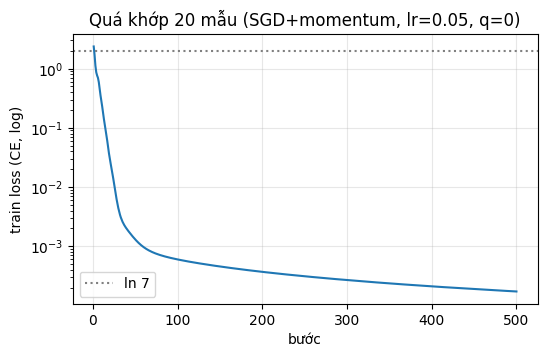

In [6]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout (q = 0), cùng model/hàm loss/optimizer như baseline, 500 bước full-batch
g = torch.Generator().manual_seed(0)
idx20 = torch.randperm(len(X_tr), generator=g)[:20].to(device)
xb20, yb20 = X_tr[idx20], y_tr[idx20]
print("nhãn của 20 mẫu:", yb20.tolist())

set_seed(1)
m20 = MLP((256, 128), dropout=0.0, init="he").to(device)
opt20 = build_optimizer("sgd_momentum", m20.parameters(), lr=0.05)   # lr chỉ dùng cho phép thử này
losses20 = []
for step in range(500):
    m20.train()
    loss = compute_loss(m20(xb20), yb20, "ce")
    opt20.zero_grad(set_to_none=True)
    loss.backward()
    opt20.step()
    losses20.append(loss.item())
acc20 = (predict(m20, xb20) == yb20).float().mean().item()
print(f"loss bước 1 = {losses20[0]:.4f}, bước 100 = {losses20[99]:.2e}, bước 500 = {losses20[-1]:.2e}; accuracy trên 20 mẫu = {acc20:.0%}")
assert losses20[-1] < 1e-2 and acc20 == 1.0

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(range(1, 501), losses20)
ax.axhline(LN7, color="gray", ls=":", label="ln 7")
ax.set(title="Quá khớp 20 mẫu (SGD+momentum, lr=0.05, q=0)", xlabel="bước", ylabel="train loss (CE, log)")
ax.grid(alpha=0.3); ax.legend()
plt.show()

In [7]:
# 1d. Gradient có chảy tới mọi tham số? Một lần forward/backward trên 512 mẫu train
model.train()
model.zero_grad(set_to_none=True)
compute_loss(model(X_tr[:512]), y_tr[:512], "ce").backward()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    for name, p in ((f"W{i}", lin.weight), (f"b{i}", lin.bias)):
        assert p.grad is not None and p.grad.norm() > 0, f"{name} không có gradient"
        print(f"{name:3s} {str(tuple(p.shape)):11s} ‖grad‖ = {p.grad.norm().item():.4e}")
print("chuẩn toàn cục:", f"{clip_gradients(model.parameters(), None):.4f}")
model.zero_grad(set_to_none=True)

W1  (256, 54)   ‖grad‖ = 5.0705e-01
b1  (256,)      ‖grad‖ = 3.4224e-01
W2  (128, 256)  ‖grad‖ = 2.0212e+00
b2  (128,)      ‖grad‖ = 4.4387e-01
W3  (7, 128)    ‖grad‖ = 1.9605e+00
b3  (7,)        ‖grad‖ = 5.7246e-01
chuẩn toàn cục: 2.9711


**Nhận xét Part 1:**
- **Model:** 47 879 tham số (assert qua), logits có shape `(8, 7)` và không có softmax trong model. std(W) khớp với He: W1 0,194 so với √(2/54) = 0,192, W2 0,088 so với 0,088, W3 0,123 so với 0,125, bias đều bằng 0. Vậy khởi tạo He thực sự được áp dụng, không phải khởi tạo mặc định của `nn.Linear`.
- **Loss bước 0** đo được là **2,2691** (seed 1), so với ln 7 = 1,9459 thì lệch +0,32. Qua 5 seed, giá trị này dao động từ 1,90 đến 2,31, quanh ln 7. Lý do: ln 7 chỉ đúng khi logits ≈ 0, tức softmax đều trên 7 lớp. He init cho lớp ra Var = 2/128, nên logits có std ≈ 0,53–0,58 (đo bằng `activation_stats`). Khi đó loss bước 0 = E[logsumexp(z)] − E[z_y]: mỗi seed vô tình "ưu ái" một số lớp, và vì nhãn mất cân bằng (lớp 0 và 1 chiếm 85%), loss cao hơn ln 7 khi init bất lợi cho các lớp lớn (seed 1, 4) và thấp hơn khi init có lợi cho chúng (seed 3). **Bằng chứng đây không phải lỗi code:** chỉ cần thu nhỏ W lớp ra ×0,01 (mọi thứ khác giữ nguyên), loss về **1,944–1,948 ≈ ln 7** ở cả 5 seed. Nếu nhãn lệch hay softmax bị áp hai lần thì phép thu nhỏ này không sửa được. Baseline vẫn giữ He cho mọi lớp đúng như quy định. Độ lệch này biến mất rất nhanh: sau epoch 1, val loss đã ≈ 0,48.
- **Quá khớp 20 mẫu** (q = 0, SGD+momentum lr 0,05): loss giảm từ 2,358 xuống 6,0·10⁻⁴ sau 100 bước và 1,7·10⁻⁴ sau 500 bước, accuracy 100%. Như vậy nhãn, hàm loss, `zero_grad` và việc optimizer nhận đủ tham số đều đúng, và mạng đủ năng lực ghi nhớ.
- **Gradient chảy tới mọi tham số:** cả 6 tensor W1, b1, …, b3 đều có ‖grad‖ khác 0, từ 0,34 (b1) đến 2,02 (W2), chuẩn toàn cục 2,97. Không có lớp nào bị "đứt" gradient.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [ ]:
# TODO: chọn lr cho baseline bằng VAL (chạy vài giá trị, ví dụ quanh 0.01 -> 0.1); ghi bảng lr -> val_macro_f1
# TODO: cfg = {**DEFAULT_CFG, "lr": <lr đã chọn>}
# TODO: chạy baseline với >= 2 seed (khuyến khích 3): result = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
# TODO: với mỗi result: save_result(result, f"{OUT_DIR}/results"); plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
# TODO: tính trung bình ± độ lệch chuẩn (val_macro_f1, val_acc) qua các seed -> ngưỡng nhiễu 2σ

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [ ]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
# TODO: exp_cfg = {**cfg, "exp_id": "...", "group": "...", "description": "...", <chỉ đổi MỘT yếu tố>}
# TODO: result = run_experiment(exp_cfg, data)
# TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
# TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ

**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [ ]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary